# 11 — Blend v2 (Full 9-Model Ensemble)

Combines all nine model OOFs (Linear Regression, Random Forest, Gradient Boosting, XGBoost v1, MLP, XGBoost v2, XGBoost v3, LightGBM, CatBoost) and re-runs SLSQP weight optimisation.

Outputs:
- `outputs/test_local_pred_blend_v2.npy`
- `outputs/blend_v2_weights.json`

In [1]:
import os
os.environ['PYTHONWARNINGS'] = 'ignore'  # also silences warnings from n_jobs=-1 joblib subprocesses

import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.optimize import minimize
warnings.filterwarnings('ignore')

OUT_DIR = Path('../outputs')
DATA_DIR = Path('../data')

In [2]:
# Load development set target (train_local) and local test target
train_local = pd.read_parquet(OUT_DIR / 'train_local.parquet')
test_local  = pd.read_parquet(OUT_DIR / 'test_local.parquet')
y = train_local['blocked_days_Q1_2026'].astype(float).values
y_test = test_local['blocked_days_Q1_2026'].astype(float).values
print(f"Dev set y shape: {y.shape} | Local Test y shape: {y_test.shape}")

oof_files = {
    'LinearRegression': 'oof_LinearRegression.npy',
    'RandomForest':     'oof_RandomForest.npy',
    'GradientBoosting': 'oof_GradientBoosting.npy',
    'XGBoost':          'oof_XGBoost.npy',
    'XGBoost v2':       'oof_XGBoostV2.npy',
    'XGBoost v3':       'oof_XGBoostV3.npy',
    'MLP':              'oof_MLP.npy',
    'LightGBM':         'oof_LightGBM.npy',
    'CatBoost':         'oof_CatBoost.npy',
}
local_test_files = {
    'LinearRegression': 'test_local_pred_LinearRegression.npy',
    'RandomForest':     'test_local_pred_RandomForest.npy',
    'GradientBoosting': 'test_local_pred_GradientBoosting.npy',
    'XGBoost':          'test_local_pred_XGBoost.npy',
    'XGBoost v2':       'test_local_pred_XGBoostV2.npy',
    'XGBoost v3':       'test_local_pred_XGBoostV3.npy',
    'MLP':              'test_local_pred_mlp.npy',
    'LightGBM':         'test_local_pred_LightGBM.npy',
    'CatBoost':         'test_local_pred_CatBoost.npy',
}
oofs, local_test_preds = {}, {}
dev_scores, test_scores = {}, {}
for name, oof_name in oof_files.items():
    p_oof = OUT_DIR / oof_name
    p_lt  = OUT_DIR / local_test_files[name]
    if p_oof.exists():
        oof_loaded = np.load(p_oof)
        if oof_loaded.shape[0] != y.shape[0]:
            print(f'{name:<18s} | SHAPE MISMATCH: {y.shape[0]} vs {oof_loaded.shape[0]} (skip)')
            continue
        oofs[name] = np.clip(oof_loaded, 0, 90)
        mse = mean_squared_error(y, oofs[name])
        mae = mean_absolute_error(y, oofs[name])
        r2  = r2_score(y, oofs[name])
        dev_scores[name] = {'MSE': mse, 'MAE': mae, 'R2': r2}
        print(f'{name:<18s} | OOF  MSE = {mse:8.3f}  MAE = {mae:7.3f}  R2 = {r2:.3f}')
    else:
        print(f'{name:<18s} | OOF MISSING ({oof_name})')
    if p_lt.exists():
        local_test_preds[name] = np.load(p_lt)
        pred = np.clip(local_test_preds[name], 0, 90)
        mse_t = mean_squared_error(y_test, pred)
        mae_t = mean_absolute_error(y_test, pred)
        r2_t  = r2_score(y_test, pred)
        test_scores[name] = {'MSE': mse_t, 'MAE': mae_t, 'R2': r2_t}
        print(f'{"":<18s} | Test MSE = {mse_t:8.3f}  MAE = {mae_t:7.3f}  R2 = {r2_t:.3f}')
    else:
        print(f'{name:<18s} | LOCAL TEST PRED MISSING')

model_names = [m for m in oofs.keys() if m in local_test_preds]
print('\nModels in blend:', model_names)

Dev set y shape: (29008,) | Local Test y shape: (7253,)
LinearRegression   | OOF  MSE =  367.267  MAE =  12.522  R2 = 0.417
                   | Test MSE =  364.726  MAE =  12.309  R2 = 0.412
RandomForest       | OOF  MSE =  308.605  MAE =  10.527  R2 = 0.510
                   | Test MSE =  304.015  MAE =  10.265  R2 = 0.510
GradientBoosting   | OOF  MSE =  447.745  MAE =  11.203  R2 = 0.289
                   | Test MSE =  436.195  MAE =  10.913  R2 = 0.297
XGBoost            | OOF  MSE =  300.199  MAE =  10.230  R2 = 0.524
                   | Test MSE =  295.539  MAE =   9.996  R2 = 0.524
XGBoost v2         | OOF  MSE =  304.178  MAE =  10.366  R2 = 0.517
                   | Test MSE =  298.878  MAE =  10.159  R2 = 0.518
XGBoost v3         | OOF  MSE =  303.480  MAE =  10.336  R2 = 0.518
                   | Test MSE =  297.817  MAE =  10.117  R2 = 0.520
MLP                | OOF  MSE =  387.573  MAE =  10.465  R2 = 0.385
                   | Test MSE =  381.386  MAE =  10.295  R2 

In [3]:
oof_mat = np.column_stack([oofs[m] for m in model_names])
print('oof_mat:', oof_mat.shape)

# Equal-weight baseline
blend_eq = np.clip(oof_mat.mean(axis=1), 0, 90)
mse_eq = mean_squared_error(y, blend_eq)
mae_eq = mean_absolute_error(y, blend_eq)
r2_eq  = r2_score(y, blend_eq)
dev_scores['Equal-Blend'] = {'MSE': mse_eq, 'MAE': mae_eq, 'R2': r2_eq}
print(f'Equal-weight blend OOF MSE = {mse_eq:.3f}  MAE = {mae_eq:.3f}  R2 = {r2_eq:.3f}')

oof_mat: (29008, 9)
Equal-weight blend OOF MSE = 306.968  MAE = 10.382  R2 = 0.513


In [4]:
def blend_mse(w, M, y):
    return float(mean_squared_error(y, np.clip(M @ w, 0, 90)))

k = oof_mat.shape[1]
w0 = np.full(k, 1.0 / k)
res = minimize(blend_mse, w0, args=(oof_mat, y),
               method='SLSQP', bounds=[(0.0, 1.0)] * k,
               constraints=[{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}],
               options={'maxiter': 500, 'ftol': 1e-9})
w = res.x; w[w < 1e-4] = 0.0; w = w / w.sum()
print('Optimal weights:')
for m, wi in zip(model_names, w):
    print(f'  {m:<18s} = {wi:.4f}')

pred_opt = np.clip(oof_mat @ w, 0, 90)
mse_opt = mean_squared_error(y, pred_opt)
mae_opt = mean_absolute_error(y, pred_opt)
r2_opt  = r2_score(y, pred_opt)
dev_scores['Optimal-Blend'] = {'MSE': mse_opt, 'MAE': mae_opt, 'R2': r2_opt}
print(f'\nOptimal blend OOF MSE = {mse_opt:.3f}  MAE = {mae_opt:.3f}  R2 = {r2_opt:.3f}')

with open(OUT_DIR / 'blend_v2_weights.json', 'w') as f:
    json.dump({m: float(wi) for m, wi in zip(model_names, w)}, f, indent=2)

Optimal weights:
  LinearRegression   = 0.0000
  RandomForest       = 0.1297
  GradientBoosting   = 0.0000
  XGBoost            = 0.5087
  XGBoost v2         = 0.0000
  XGBoost v3         = 0.1602
  MLP                = 0.0409
  LightGBM           = 0.0987
  CatBoost           = 0.0619

Optimal blend OOF MSE = 297.966  MAE = 10.214  R2 = 0.527


In [5]:
# Build local test blend prediction
test_mat = np.column_stack([local_test_preds[m] for m in model_names])
final_lt = np.clip(test_mat @ w, 0, 90)
test_mse_blend_v2 = mean_squared_error(y_test, final_lt)
test_mae_blend_v2 = mean_absolute_error(y_test, final_lt)
test_r2_blend_v2  = r2_score(y_test, final_lt)
test_scores['Optimal-Blend'] = {'MSE': test_mse_blend_v2, 'MAE': test_mae_blend_v2, 'R2': test_r2_blend_v2}
print(f'Blend v2 Local Test MSE = {test_mse_blend_v2:.3f}  MAE = {test_mae_blend_v2:.3f}  R2 = {test_r2_blend_v2:.3f}')
np.save(OUT_DIR / 'test_local_pred_blend_v2.npy', final_lt)
print(f'Saved test_local_pred_blend_v2.npy | mean={final_lt.mean():.2f}')

Blend v2 Local Test MSE = 294.607  MAE = 10.009  R2 = 0.525
Saved test_local_pred_blend_v2.npy | mean=15.69


=== Dev (5-Fold OOF) metrics ===
                      MSE     MAE     R2
model                                   
Optimal-Blend     297.966  10.214  0.527
XGBoost           300.199  10.230  0.524
XGBoost v3        303.480  10.336  0.518
XGBoost v2        304.178  10.366  0.517
LightGBM          305.358  10.350  0.515
CatBoost          306.282  10.495  0.514
Equal-Blend       306.968  10.382  0.513
RandomForest      308.605  10.527  0.510
LinearRegression  367.267  12.522  0.417
MLP               387.573  10.465  0.385
GradientBoosting  447.745  11.203  0.289

=== Local Test metrics ===
                      MSE     MAE     R2
model                                   
Optimal-Blend     294.607  10.009  0.525
XGBoost           295.539   9.996  0.524
XGBoost v3        297.817  10.117  0.520
XGBoost v2        298.878  10.159  0.518
LightGBM          299.485  10.140  0.517
CatBoost          303.620  10.313  0.511
RandomForest      304.015  10.265  0.510
LinearRegression  364.726  12.309  0.

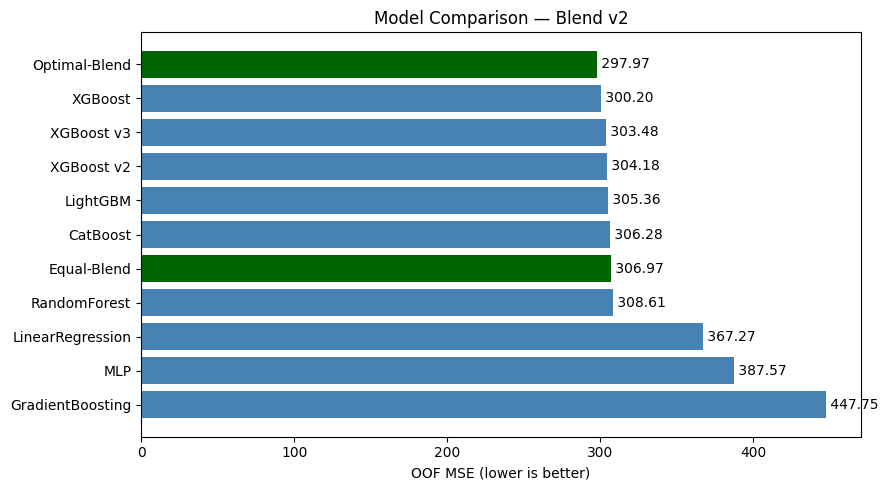

In [6]:
# Full metrics summary + comparison plot
summary_dev = pd.DataFrame(dev_scores).T[['MSE', 'MAE', 'R2']].round(3).sort_values('MSE')
summary_dev.index.name = 'model'
print('=== Dev (5-Fold OOF) metrics ===')
print(summary_dev.to_string())

summary_test = pd.DataFrame(test_scores).T[['MSE', 'MAE', 'R2']].round(3).sort_values('MSE')
summary_test.index.name = 'model'
print('\n=== Local Test metrics ===')
print(summary_test.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['darkgreen' if 'Blend' in n else 'steelblue' for n in summary_dev.index]
ax.barh(summary_dev.index, summary_dev['MSE'].values, color=colors)
for i, v in enumerate(summary_dev['MSE'].values):
    ax.text(v, i, f' {v:.2f}', va='center')
ax.invert_yaxis()
ax.set_xlabel('OOF MSE (lower is better)')
ax.set_title('Model Comparison — Blend v2')
plt.tight_layout(); plt.savefig(OUT_DIR / 'blend_v2_comparison.png', dpi=120); plt.show()